In [1]:
# Data Cleaning & Reporting Automation

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"C:\Users\saiki\Desktop\Project1A\Project_4\Project4_Raw_Data.csv")

In [5]:
df.head()

,Customer_ID,Age,Gender,City,Purchase_Amount,Segment,Signup_Date
0,CUST10000,NaN,female,Mumbai,NaN,NaN,06-16-24
1,CUST10001,46.0,Female,Hyderabad,12527.0,Premium,11-18-25
2,CUST10002,32.0,male,Hyderabad,46650.0,VIP,11-05-24
3,CUST10003,60.0,male,Mumbai,20666.0,Premium,04-23-25
4,CUST10004,25.0,Female,Chennai,2330.0,NaN,02-25-24


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer_ID      1520 non-null   object 
 1   Age              1491 non-null   float64
 2   Gender           1380 non-null   object 
 3   City             1217 non-null   object 
 4   Purchase_Amount  1481 non-null   float64
 5   Segment          1146 non-null   object 
 6   Signup_Date      1520 non-null   object 
dtypes: float64(2), object(5)
memory usage: 83.3+ KB


In [7]:
df.describe()

,Age,Purchase_Amount
count,1491.000000,1481.000000
mean,41.182428,24975.419986
std,13.409462,14575.689809
min,18.000000,116.000000
25%,29.000000,12406.000000
50%,42.000000,24981.000000
75%,52.000000,37810.000000
max,64.000000,49977.000000


In [8]:
df.isnull().sum()

Customer_ID          0
Age                 29
Gender             140
City               303
Purchase_Amount     39
Segment            374
Signup_Date          0
dtype: int64

In [9]:
df["Age"]=df["Age"].fillna(df["Age"].mean())
df["Purchase_Amount"]=df["Purchase_Amount"].fillna(df["Purchase_Amount"].mean())

In [10]:
df["Gender"]=df["Gender"].fillna(df["Gender"].mode()[0])
df["City"]=df["City"].fillna(df["City"].mode()[0])
df["Segment"]=df["Segment"].fillna(df["Segment"].mode()[0])

In [11]:
df.duplicated().sum()

np.int64(20)

In [12]:
df=df.drop_duplicates()

In [13]:
df["Gender"]=df["Gender"].str.capitalize()

In [15]:
df["Signup_Date"] = pd.to_datetime(df["Signup_Date"], errors="coerce")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer_ID      1500 non-null   object        
 1   Age              1500 non-null   float64       
 2   Gender           1500 non-null   object        
 3   City             1500 non-null   object        
 4   Purchase_Amount  1500 non-null   float64       
 5   Segment          1500 non-null   object        
 6   Signup_Date      1500 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 93.8+ KB


In [17]:
df.isnull().sum()

Customer_ID        0
Age                0
Gender             0
City               0
Purchase_Amount    0
Segment            0
Signup_Date        0
dtype: int64

In [18]:
print("Total Records:", len(df))
print("Average Age:", round(df["Age"].mean(),2))
print("Average Purchase:",round(df["Purchase_Amount"].mean(),2))

Total Records: 1500
Average Age: 41.2
Average Purchase: 25025.22


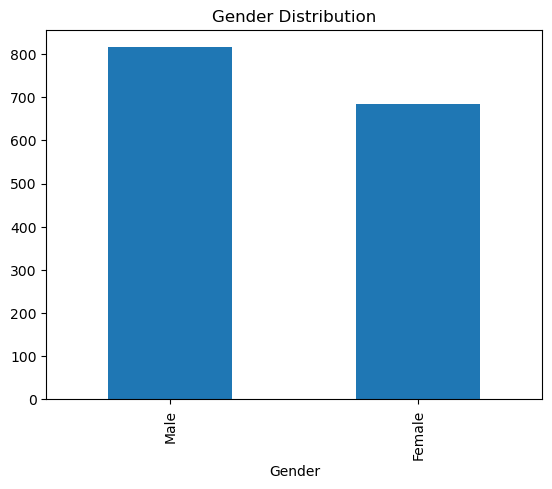

In [19]:
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.show()

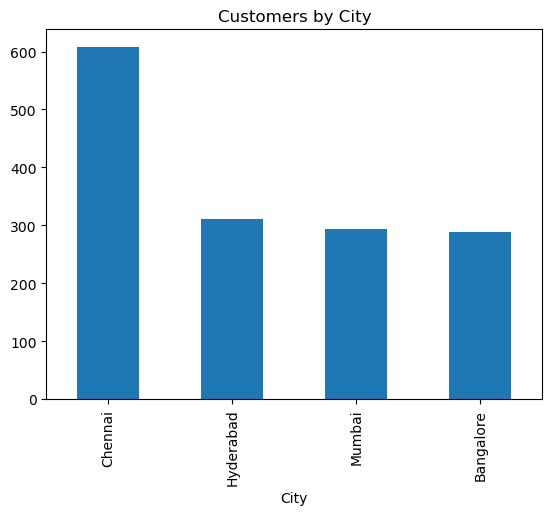

In [20]:
df["City"].value_counts().plot(kind="bar")
plt.title("Customers by City")
plt.show()

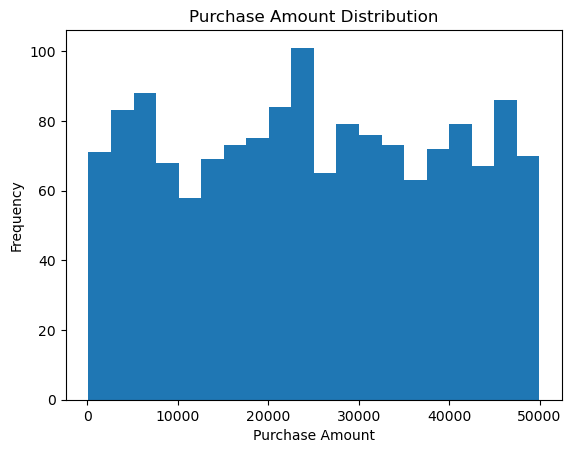

In [21]:
plt.hist(df["Purchase_Amount"], bins=20)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Frequency")
plt.show()

In [22]:
df.to_csv("cleaned_customer_data.csv",index=False)